# L13b: Self-Attention for Sarcasm Classification in News Headlines
In this lab, we train a multi-head self-attention classifier with positional encoding to detect sarcasm in news headlines from [the Sarcasm Headlines Dataset v2](https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection) and compare its performance against a mean-pooled bag-of-embeddings baseline.

> __Learning Objectives__
>
> By the end of this lab, you should be able to:
>
> * __Build a multi-head self-attention classifier for binary text classification:__ Construct a multi-head scaled dot-product self-attention layer with sinusoidal positional encoding, masked mean-pooling, and a two-layer MLP head to classify headlines as sarcastic or not sarcastic. Connect each component to the attention equations from the L13a lecture.
> * __Train and evaluate on real-world headline data:__ Load real news headlines from the Sarcasm Headlines Dataset v2, embed them as padded GloVe sequences, and train the classifier with cross-entropy loss and the Adam optimizer. Measure test accuracy and confusion matrices on a held-out split.
> * __Visualize attention weights to interpret sarcasm detection:__ Extract the learned attention weight matrices and plot heatmaps on sarcastic headlines to see which tokens the model attends to. Compare the attention model against a mean-pool baseline on the same data.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __What is the `Include.jl` file?__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file in the global scope of the containing module. The `Include.jl` file loads all required packages and source files.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b`


In addition to standard Julia libraries, this lab uses [the `Flux.jl` package](https://fluxml.ai/Flux.jl/stable/) for neural network layers and gradient-based optimization, [`NNlib.jl`](https://github.com/FluxML/NNlib.jl) for batched matrix operations and softmax, [`OneHotArrays.jl`](https://github.com/FluxML/OneHotArrays.jl) for one-hot label encoding, [`JSON.jl`](https://github.com/JuliaIO/JSON.jl) for parsing the JSONL dataset, [`JLD2.jl`](https://github.com/JuliaIO/JLD2.jl) for model checkpointing, [`Plots.jl`](https://docs.juliaplots.org/stable/) for visualization, and [`PrettyTables.jl`](https://github.com/ronisbr/PrettyTables.jl) for formatted table output.

### Data
We use [Stanford GloVe 6B 100-dimensional embeddings](https://nlp.stanford.edu/projects/glove/) for word representations. The [Sarcasm Headlines Dataset v2](https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection) contains 28,619 news headlines from The Onion (sarcastic) and HuffPost (not sarcastic) in JSONL format with fields `is_sarcastic`, `headline`, and `article_link`.

We first load the GloVe embeddings, then parse the sarcasm dataset.

In [2]:
# check: do we have a local copy of the GloVe embeddings? If not, download them.
glove_path = joinpath(_PATH_TO_DATA, "glove.6B.100d.txt");
isfile(glove_path) || (glove_path = download_glove(_PATH_TO_DATA; dim=100));
glove = load_glove_embeddings(glove_path);
@info "GloVe loaded" n_words=length(glove);

┌ Info: GloVe loaded
│   n_words = 400000
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y155sZmlsZQ==.jl:5


Next, we load the sarcasm headlines from the JSONL file into a DataFrame.

In [3]:
headlines_df = let

    # parse each line of the JSONL file into a vector of dictionaries
    records = Vector{Dict{String,Any}}();
    open(joinpath(_PATH_TO_DATA, "Sarcasm_Headlines_Dataset_v2.txt")) do f
        for line in eachline(f)
            push!(records, JSON.parse(line));
        end
    end

    # build DataFrame with headline text and integer sarcasm label
    DataFrame(
        headline = String[r["headline"] for r in records],
        is_sarcastic = Int[r["is_sarcastic"] for r in records]
    )
end;
@info "Headlines loaded" n=nrow(headlines_df);
class_counts = combine(groupby(headlines_df, :is_sarcastic), nrow => :count);
pretty_table(class_counts)

┌ Info: Headlines loaded
│   n = 28619
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y160sZmlsZQ==.jl:17


┌──────────────┬───────┐
│ is_sarcastic │ count │
│        Int64 │ Int64 │
├──────────────┼───────┤
│            0 │ 14985 │
│            1 │ 13634 │
└──────────────┴───────┘


### Implementations
We use helper functions defined in this notebook and in the `src/` directory:

| Function | Source | Description |
| --- | --- | --- |
| `confusion_matrix(...)` | notebook | Build a confusion matrix from true and predicted label indices |
| `plot_attention(...)` | notebook | Extract attention weights and render as a heatmap |
| [`sinusoidal_pe(...)`](src/Attention.jl) | `src/Attention.jl` | Compute sinusoidal positional encoding matrix |
| [`SelfAttention(...)`](src/Attention.jl) | `src/Attention.jl` | Single-head scaled dot-product self-attention layer |
| [`MultiHeadAttention(...)`](src/Attention.jl) | `src/Attention.jl` | Multi-head self-attention with output projection |
| [`AttentionClassifier(...)`](src/Attention.jl) | `src/Attention.jl` | PE + multi-head attention + masked mean-pool + MLP head |
| [`embed_reviews_sequence(...)`](src/Embeddings.jl) | `src/Embeddings.jl` | Embed text as padded GloVe token sequences |
| [`embed_reviews(...)`](src/Embeddings.jl) | `src/Embeddings.jl` | Embed text as mean-pooled GloVe vectors (baseline) |
| [`load_glove_embeddings(...)`](src/GloVeUtils.jl) | `src/GloVeUtils.jl` | Load GloVe word vectors from text file |

In [4]:
"""Build a confusion matrix C where C[t, p] counts how many times true class t was predicted as class p."""
function confusion_matrix(y_true_idx::Vector{Int}, y_pred_idx::Vector{Int}, n_classes::Int)
    C = zeros(Int, n_classes, n_classes); # initialize n_classes × n_classes matrix of zeros
    for (t, p) in zip(y_true_idx, y_pred_idx)
        C[t, p] += 1; # increment the count for (true class t, predicted class p)
    end
    return C;
end

confusion_matrix

Next, we define the attention visualization function.

In [5]:
"""Extract the attention weight matrix from a trained model and render it as a heatmap."""
function plot_attention(model::AttentionClassifier, X_one::AbstractArray{<:Real, 3},
                          mask_one::AbstractMatrix{Bool}, tokens_one::Vector{String};
                          title_str::String="attention")

    w = attention_weights(model, X_one, mask_one);              # (n, n, 1) attention weight tensor
    n_valid = sum(mask_one);                                     # number of real (non-padding) tokens
    A = collect(Float64.(w[1:n_valid, 1:n_valid, 1]));          # extract the valid region as a dense matrix
    toks = tokens_one[1:n_valid];                                # token strings for axis labels

    # plot: use integer axes with manual tick labels to avoid Plots.jl sorting strings alphabetically
    heatmap(1:n_valid, 1:n_valid, A;
            xticks=(1:n_valid, toks), yticks=(1:n_valid, toks),
            xlabel="key (attended-to token)",
            ylabel="query (attending token)",
            title=title_str,
            xrotation=60, color=:viridis,
            size=(700, 600), yflip=true)
end

plot_attention

### Constants
We define constants used throughout the lab. The embedding dimension `D_EMB` matches the GloVe vector size, and the maximum sequence length `N_MAX` controls padding and truncation of each headline. Headlines are short (median around 10 tokens), so `N_MAX = 20` covers the vast majority of the data without excess padding.

We embed each headline as a padded sequence of GloVe vectors stored in `X_seq`, with a boolean padding mask in `mask` and per-headline token strings in `tokens_str`.

In [6]:
const D_EMB = 100;   # GloVe embedding dimension
const N_MAX = 20;    # max sequence length (pad or truncate each headline to this length)

# embed each headline as a padded sequence of GloVe vectors
X_seq, mask, tokens_str = embed_reviews_sequence(
    string.(headlines_df.headline), glove; dim=D_EMB, n_max=N_MAX);
@info "Padded sequences" X_shape=size(X_seq) mask_shape=size(mask)

┌ Info: Padded sequences
│   X_shape = (100, 20, 28619)
│   mask_shape = (20, 28619)
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y166sZmlsZQ==.jl:7


Next, we encode the binary labels (not sarcastic / sarcastic) as integer indices and one-hot vectors. The label mapping follows the order `["not_sarcastic", "sarcastic"]` so that index 1 corresponds to not sarcastic and index 2 corresponds to sarcastic.

In [7]:
const CLASS_NAMES = ["not_sarcastic", "sarcastic"];
const N_CLASSES = length(CLASS_NAMES);

# map is_sarcastic (0/1) to class index (1/2): 0 → 1 (not_sarcastic), 1 → 2 (sarcastic)
y_idx = headlines_df.is_sarcastic .+ 1;
y_onehot = Float32.(Flux.onehotbatch(y_idx, 1:N_CLASSES));

We then take an 80/20 train/test split. The training and test tensors are stored in `X_train_seq`, `mask_train`, `y_train` and `X_test_seq`, `mask_test`, `y_test`. The index arrays `TRAIN_IDX` and `TEST_IDX` store which headlines belong to each split, for use when comparing against the baseline.

In [8]:
X_train_seq, mask_train, y_train, X_test_seq, mask_test, y_test, TRAIN_IDX, TEST_IDX = let

    # shuffle and split into 80% train / 20% test
    Random.seed!(42);
    N = size(X_seq, 3);
    perm = randperm(N);
    n_train = round(Int, 0.8 * N);
    train_idx = perm[1:n_train];
    test_idx  = perm[n_train+1:end];

    X_train_seq = X_seq[:, :, train_idx];
    mask_train  = mask[:, train_idx];
    y_train     = y_onehot[:, train_idx];
    X_test_seq  = X_seq[:, :, test_idx];
    mask_test   = mask[:, test_idx];
    y_test      = y_onehot[:, test_idx];

    @info "Train/test split" n_train=size(X_train_seq, 3) n_test=size(X_test_seq, 3)

    # return -
    (X_train_seq, mask_train, y_train, X_test_seq, mask_test, y_test, train_idx, test_idx)
end;

┌ Info: Train/test split
│   n_train = 22895
│   n_test = 5724
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y203sZmlsZQ==.jl:18


___

## Task 1: Build the Self-Attention Classifier
The model is built from four pieces, all defined in [src/Attention.jl](src/Attention.jl).

> __Architecture__
>
> * __Sinusoidal positional encoding__: added to the GloVe token embeddings before attention. Self-attention is permutation-equivariant, so without positional encoding the model has no sense of word order. Sarcasm often depends on word positioning, so this information is critical.
> * __Multi-head self-attention__: instead of a single attention head, we use multiple heads in parallel, each with its own learned projection matrices. The heads' outputs are concatenated and projected through a learned output matrix $\mathbf{W}_{O}$. This allows the model to attend to different aspects of the input simultaneously.
> * __Masked mean-pooling__: averages the attention output over non-padding positions to produce a single fixed-size vector per headline.
> * __MLP head__: a two-layer feed-forward network (`Dense` $\rightarrow$ `relu` $\rightarrow$ `Dense`) that maps the pooled vector to 2-class logits (not sarcastic vs. sarcastic).

We initialize the model with $d_{k} = d_{v} = 64$, $n_{\text{heads}} = 4$, and hidden layer width $d_{\text{hidden}} = 64$.

In [9]:
model, n_params, D_HIDDEN = let

    # initialize - set the projection and hidden dimensions
    d_k = 128;          # query/key projection dimension per head
    d_v = 128;          # value projection dimension per head
    n_heads = 10;        # number of parallel attention heads
    d_hidden = 64;      # MLP hidden layer width (used later for baseline)

    # build the multi-head self-attention classifier with positional encoding
    Random.seed!(42);
    model = AttentionClassifier(D_EMB, d_k, d_v, n_heads, d_hidden, N_CLASSES; n_max=N_MAX);
    n_params = sum(length, Flux.trainables(model)); # count total trainable parameters
    @info "multi-head self-attention classifier" n_params=n_params d_emb=D_EMB d_k=d_k d_v=d_v n_heads=n_heads d_hidden=d_hidden n_classes=N_CLASSES

    # return -
    (model, n_params, d_hidden)
end

┌ Info: multi-head self-attention classifier
│   n_params = 556226
│   d_emb = 100
│   d_k = 128
│   d_v = 128
│   n_heads = 10
│   d_hidden = 64
│   n_classes = 2
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y206sZmlsZQ==.jl:13


(AttentionClassifier{MultiHeadAttention}(Float32[0.0 0.84147096 … -0.75098723 0.1498772; 1.0 0.5403023 … 0.6603167 0.9887046; … ; 0.0 0.00012022642 … 0.0021640738 0.0022842998; 1.0 1.0 … 0.9999977 0.9999974], MultiHeadAttention(SelfAttention[SelfAttention(Float32[0.07883556 -0.06705636 … 0.19785559 -0.07912814; -0.087985866 0.07137771 … 0.022944331 0.02424552; … ; 0.22573511 0.11661624 … -0.008333579 0.09315136; 0.050030667 -0.067069866 … -0.018235428 -0.106130324], Float32[0.020821651 -0.108817056 … 0.0726191 0.003956377; -0.07870626 0.049443573 … 0.026788129 -0.020253105; … ; -0.045858398 -0.02680615 … 0.03333608 -0.027607733; 0.047474455 -0.16352673 … 0.048167244 0.08839378], Float32[0.05098618 0.043923393 … -0.12984078 -0.048170872; -0.044971388 -0.012570045 … 0.13705646 0.04253401; … ; 0.068702064 0.08714312 … -0.12571512 0.106395185; 0.052182883 0.033773284 … 0.0046304404 0.063670866]), SelfAttention(Float32[-0.033517536 -0.05858287 … -0.10389232 0.018488578; 0.14717959 -0.107092

___

## Task 2: Train the Self-Attention Classifier
We train with Adam at learning rate $3\times 10^{-3}$ for $30$ epochs at batch size $32$. The first run trains and saves a checkpoint to `data/attention_sarcasm_H64.jld2`; subsequent runs load the checkpoint to skip retraining.

> __Training details__
>
> The loss function is logit cross-entropy (`Flux.logitcrossentropy`), which combines softmax and cross-entropy in a numerically stable way. We use mini-batch stochastic gradient descent with the Adam optimizer. The training indices are reshuffled each epoch.

In [10]:
train_loss_history = let

    # initialize -
    checkpoint_path = joinpath(_PATH_TO_DATA, "attention_sarcasm_H64.jld2");
    n_epochs = 100;      # number of training epochs
    batchsize = 128;      # mini-batch size for SGD
    train_loss_history = Float32[];

    if isfile(checkpoint_path)
        # checkpoint exists: load saved model weights and loss history instead of retraining
        @info "Loading pre-trained checkpoint" path=checkpoint_path
        saved = JLD2.load(checkpoint_path);
        Flux.loadmodel!(model, saved["model_state"]);
        train_loss_history = saved["train_loss_history"];
        @info "Loaded model from checkpoint"
    else
        # no checkpoint: train from scratch with Adam optimizer
        @info "No checkpoint found, training from scratch..."
        Random.seed!(42);
        opt = Flux.setup(Adam(3.0f-3), model); # Adam optimizer with learning rate 3e-3
        n_tr = size(X_train_seq, 3);           # number of training headlines

        for epoch in 1:n_epochs
            epoch_losses = Float32[];
            perm_e = randperm(n_tr); # shuffle training indices each epoch

            # mini-batch training loop
            for i in 1:batchsize:n_tr
                idxs = perm_e[i:min(i + batchsize - 1, n_tr)]; # batch indices
                Xb = X_train_seq[:, :, idxs];   # batch token sequences
                mb = mask_train[:, idxs];         # batch masks
                yb = y_train[:, idxs];            # batch one-hot labels

                # compute loss and gradients, then update model parameters
                l, gs = Flux.withgradient(model) do m
                    Flux.logitcrossentropy(m(Xb, mb), yb)
                end
                push!(epoch_losses, l);
                Flux.update!(opt, model, gs[1]);
            end

            push!(train_loss_history, mean(epoch_losses));

            # log train/test accuracy every 5 epochs (and epoch 1)
            if epoch == 1 || epoch % 5 == 0
                tr_logits = model(X_train_seq, mask_train);
                tr_acc = mean(Flux.onecold(tr_logits) .== Flux.onecold(y_train));
                te_logits = model(X_test_seq, mask_test);
                te_acc = mean(Flux.onecold(te_logits) .== Flux.onecold(y_test));
                @info "epoch" epoch loss=round(mean(epoch_losses), digits=4) train_acc=round(tr_acc, digits=3) test_acc=round(te_acc, digits=3)
            end
        end

        # save checkpoint so we can skip training on future runs
        JLD2.jldsave(checkpoint_path; model_state = Flux.state(model), train_loss_history = train_loss_history);
        @info "Saved checkpoint" path=checkpoint_path
    end

    # return -
    train_loss_history
end;

┌ Info: No checkpoint found, training from scratch...
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y212sZmlsZQ==.jl:18
┌ Info: epoch
│   epoch = 1
│   loss = 0.6266
│   train_acc = 0.836
│   test_acc = 0.819
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y212sZmlsZQ==.jl:50
┌ Info: epoch
│   epoch = 5
│   loss = 0.2822
│   train_acc = 0.888
│   test_acc = 0.831
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y212sZmlsZQ==.jl:50
┌ Info: epoch
│   epoch = 10
│   loss = 0.1984
│   train_acc = 0.938
│   test_acc = 0.843
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CH

The per-epoch average training loss values are stored in `train_loss_history`. Let's plot the training loss to verify that the model converges.

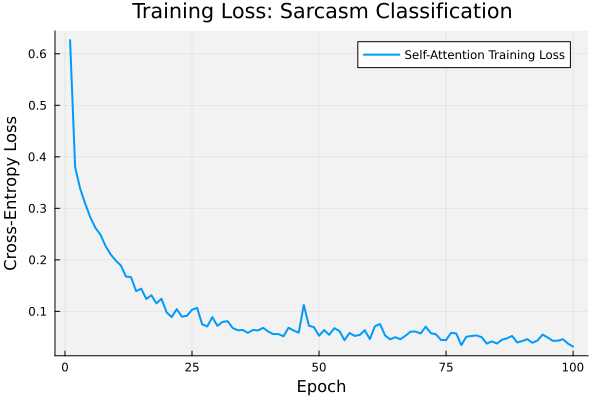

In [11]:
let
    # plot per-epoch training loss to verify convergence
    plot(1:length(train_loss_history), train_loss_history;
         xlabel="Epoch", ylabel="Cross-Entropy Loss",
         label="Self-Attention Training Loss",
         lw=2, legend=:topright,
         background_color_inside=:gray95,
         title="Training Loss: Sarcasm Classification")
end

___

## Task 3: Evaluate and Compare with Baseline
We compute test accuracy and a confusion matrix to see how well the self-attention model distinguishes sarcastic from non-sarcastic headlines. Then we train the mean-pool baseline on the same split for a direct comparison.

> __Evaluation__
>
> We use `Flux.onecold` to convert logits to predicted class indices, compute accuracy as the fraction of correct predictions, and build a confusion matrix to see the error pattern. The baseline is a two-layer MLP (`Dense` $\rightarrow$ `relu` $\rightarrow$ `Dense`) that takes the mean GloVe vector as input instead of the full token sequence.

In [12]:
test_pred, test_true, test_acc, C_attn, cm_labels = let

    # compute predictions on the held-out test set
    test_logits = model(X_test_seq, mask_test);               # (n_classes, n_test) logits
    test_pred = Flux.onecold(test_logits);              # predicted class indices
    test_true = Flux.onecold(y_test);                   # true class indices
    test_acc = mean(test_pred .== test_true);           # test accuracy
    @info "self-attention test accuracy" acc=round(test_acc, digits=4)

    # build and display the confusion matrix (rows = true class, cols = predicted class)
    C_attn = confusion_matrix(test_true, test_pred, N_CLASSES);
    cm_labels = ["true \\ pred"; CLASS_NAMES];
    println("Confusion matrix (rows = true, cols = predicted):");
    rows = [[CLASS_NAMES[i]; C_attn[i, :]] for i in 1:N_CLASSES];
    pretty_table(reduce(vcat, [permutedims(r) for r in rows]); column_labels=cm_labels)

    # return -
    (test_pred, test_true, test_acc, C_attn, cm_labels)
end

┌ Info: self-attention test accuracy
│   acc = 0.8298
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y220sZmlsZQ==.jl:8


Confusion matrix (rows = true, cols = predicted):
┌───────────────┬───────────────┬───────────┐
│  true \\ pred │ not_sarcastic │ sarcastic │
├───────────────┼───────────────┼───────────┤
│ not_sarcastic │          2633 │       348 │
│     sarcastic │           626 │      2117 │
└───────────────┴───────────────┴───────────┘


([1, 1, 1, 1, 1, 2, 1, 1, 1, 2  …  1, 1, 1, 2, 1, 1, 2, 2, 2, 1], [1, 1, 1, 1, 2, 2, 1, 1, 1, 2  …  1, 1, 1, 2, 1, 1, 2, 2, 2, 1], 0.8298392732354997, [2633 348; 626 2117], ["true \\ pred", "not_sarcastic", "sarcastic"])

Now we train the mean-pool baseline on the same train/test indices for a direct comparison. We first re-embed the headlines as mean-pooled GloVe vectors.

In [13]:
# re-embed headlines as mean-pooled vectors (bag-of-embeddings baseline)
X_mean = embed_reviews(string.(headlines_df.headline), glove; dim=D_EMB); # (d, N) matrix
X_train_mean = X_mean[:, TRAIN_IDX];
X_test_mean  = X_mean[:, TEST_IDX];

Next, we train the baseline model on the same split and evaluate its test accuracy.

In [14]:
baseline, n_baseline_params, baseline_loss_history, baseline_pred, baseline_acc = let

    # build the mean-pool baseline: same MLP head architecture, but input is a single mean vector
    Random.seed!(42);
    baseline = Chain(Dense(D_EMB => D_HIDDEN, relu), Dense(D_HIDDEN => N_CLASSES));
    n_baseline_params = sum(length, Flux.trainables(baseline));
    @info "mean-pool baseline" n_params=n_baseline_params

    # train with Adam for the same number of epochs and batch size as the self-attention model
    n_epochs = 30;
    batchsize = 32;
    opt_b = Flux.setup(Adam(3.0f-3), baseline);
    baseline_loss_history = Float32[];
    n_tr = size(X_train_mean, 2);

    for epoch in 1:n_epochs
        epoch_losses = Float32[];
        perm_e = randperm(n_tr); # shuffle each epoch
        for i in 1:batchsize:n_tr
            idxs = perm_e[i:min(i + batchsize - 1, n_tr)];
            Xb = X_train_mean[:, idxs];  # batch of mean-pooled vectors
            yb = y_train[:, idxs];        # batch of one-hot labels
            l, gs = Flux.withgradient(baseline) do m
                Flux.logitcrossentropy(m(Xb), yb)
            end
            push!(epoch_losses, l);
            Flux.update!(opt_b, baseline, gs[1]);
        end
        push!(baseline_loss_history, mean(epoch_losses));
    end

    # evaluate baseline on the same test set
    baseline_pred = Flux.onecold(baseline(X_test_mean)); # predicted class indices
    baseline_acc = mean(baseline_pred .== test_true);     # test accuracy
    @info "mean-pool baseline test accuracy" acc=round(baseline_acc, digits=4)

    # display baseline confusion matrix
    C_base = confusion_matrix(test_true, baseline_pred, N_CLASSES);
    println("Baseline confusion matrix (rows = true, cols = predicted):");
    rows_b = [[CLASS_NAMES[i]; C_base[i, :]] for i in 1:N_CLASSES];
    pretty_table(reduce(vcat, [permutedims(r) for r in rows_b]); column_labels=cm_labels)

    # return -
    (baseline, n_baseline_params, baseline_loss_history, baseline_pred, baseline_acc)
end

┌ Info: mean-pool baseline
│   n_params = 6594
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y224sZmlsZQ==.jl:7
┌ Info: mean-pool baseline test accuracy
│   acc = 0.7722
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y224sZmlsZQ==.jl:35


Baseline confusion matrix (rows = true, cols = predicted):
┌───────────────┬───────────────┬───────────┐
│  true \\ pred │ not_sarcastic │ sarcastic │
├───────────────┼───────────────┼───────────┤
│ not_sarcastic │          2389 │       592 │
│     sarcastic │           712 │      2031 │
└───────────────┴───────────────┴───────────┘


(Chain(Dense(100 => 64, relu), Dense(64 => 2)), 6594, Float32[0.54664725, 0.48971912, 0.46735805, 0.44429868, 0.42917117, 0.41571134, 0.40257245, 0.39225352, 0.38217077, 0.37208337  …  0.30235967, 0.29962155, 0.29591867, 0.2892275, 0.28770667, 0.28263602, 0.27669495, 0.2724843, 0.26899803, 0.2670525], [1, 1, 2, 1, 2, 2, 1, 1, 1, 2  …  1, 1, 2, 1, 1, 2, 1, 1, 2, 1], 0.7721872816212438)

Let's compare the two architectures side by side.

In [15]:
let
    # side-by-side comparison of the two architectures
    comparison = DataFrame(
        architecture = ["Mean-pool baseline", "Single-head self-attention"],
        n_params = [n_baseline_params, n_params],
        test_accuracy = [round(baseline_acc, digits=4), round(test_acc, digits=4)],
    );
    pretty_table(comparison)
end

┌────────────────────────────┬──────────┬───────────────┐
│               architecture │ n_params │ test_accuracy │
│                     String │    Int64 │       Float64 │
├────────────────────────────┼──────────┼───────────────┤
│         Mean-pool baseline │     6594 │        0.7722 │
│ Single-head self-attention │   556226 │        0.8298 │
└────────────────────────────┴──────────┴───────────────┘


### Visualizing attention weights on sarcastic headlines
Each row of the attention matrix is a probability distribution over the keys, telling us how much that query attends to each key. We pick sarcastic headlines where the self-attention model classifies correctly but the baseline fails, to see what the attention mechanism picks up on.

We search for these headlines in the test set.

In [16]:
sarc_candidates = let

    # compute both models' predictions on the test set
    attn_pred_test = Flux.onecold(model(X_test_seq, mask_test));
    base_pred_test = Flux.onecold(baseline(X_test_mean));
    SARC_IDX = 2;  # sarcastic class index

    # find sarcastic headlines where attention is correct but baseline fails
    candidates = Int[];
    for i in 1:length(test_true)
        if test_true[i] == SARC_IDX &&
           attn_pred_test[i] == SARC_IDX &&
           base_pred_test[i] != SARC_IDX
            push!(candidates, i);
        end
    end
    @info "Sarcastic headlines: attention correct, baseline wrong" n=length(candidates)

    # show the first few candidate headlines
    for i in candidates[1:min(5, length(candidates))]
        println("  $(headlines_df.headline[TEST_IDX[i]])")
    end

    # return -
    candidates
end

┌ Info: Sarcastic headlines: attention correct, baseline wrong
│   n = 419
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y231sZmlsZQ==.jl:17


  congress raises killing age to 19
  even consumer's subconscious can tell banner ad campaign ineffective
  maple tree wishes it was given a say in becoming memorial to man's dead wife
  scout returns with news of quicker checkout line to the east
  jack palance still dead at 87


419-element Vector{Int64}:
   23
   56
   65
   71
   92
  146
  149
  165
  183
  207
    ⋮
 5620
 5646
 5655
 5660
 5669
 5684
 5718
 5721
 5722

Let's plot the attention heatmap for the first sarcastic headline where self-attention succeeds but the baseline fails.

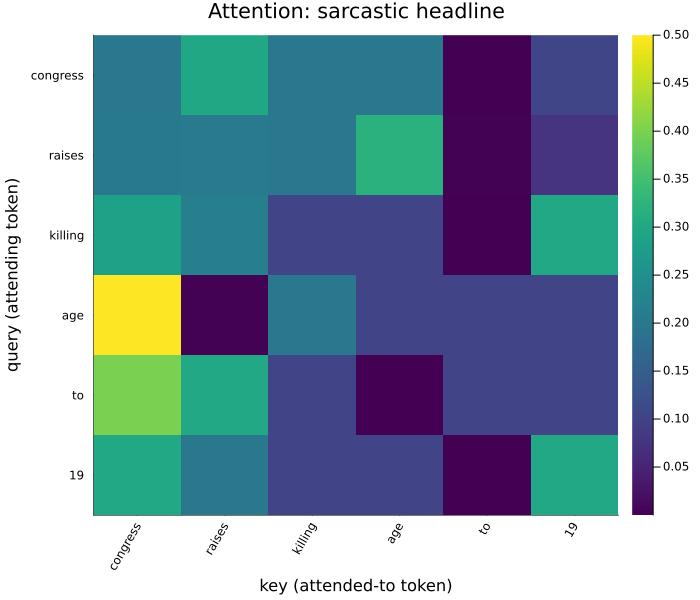

In [17]:
let
    # plot the attention heatmap for the first sarcastic candidate
    si = sarc_candidates[1];
    plot_attention(model,
                   X_test_seq[:, :, si:si],        # single headline token sequence
                   mask_test[:, si:si],             # single headline mask
                   tokens_str[:, TEST_IDX[si]];     # token strings for axis labels
                   title_str="Attention: sarcastic headline")
end

Let's also visualize the attention pattern on a non-sarcastic headline for comparison.

Non-sarcastic headline: the first chapter of harper lee's 'go set a watchman' has arrived, and readers are thrilled


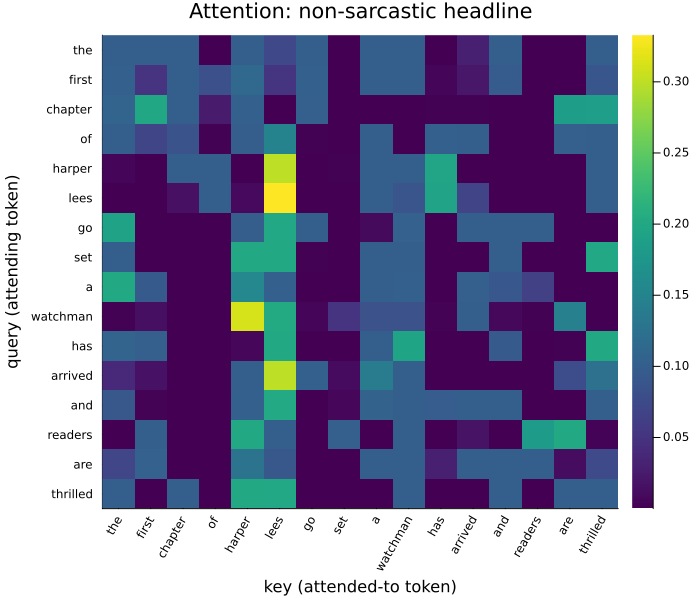

In [18]:
let
    # find a non-sarcastic headline that both models classify correctly
    attn_pred_test = Flux.onecold(model(X_test_seq, mask_test));
    base_pred_test = Flux.onecold(baseline(X_test_mean));
    NOT_SARC_IDX = 1;

    ni = findfirst(i -> test_true[i] == NOT_SARC_IDX &&
                        attn_pred_test[i] == NOT_SARC_IDX &&
                        base_pred_test[i] == NOT_SARC_IDX,
                   1:length(test_true));

    println("Non-sarcastic headline: $(headlines_df.headline[TEST_IDX[ni]])")
    plot_attention(model,
                   X_test_seq[:, :, ni:ni],
                   mask_test[:, ni:ni],
                   tokens_str[:, TEST_IDX[ni]];
                   title_str="Attention: non-sarcastic headline")
end

### Things to think about
The attention heatmaps above let you see _which tokens the model is looking at_ when it makes its prediction. A few questions to think through:

* __What distinguishes the attention pattern on sarcastic vs. non-sarcastic headlines?__ Sarcastic headlines from The Onion often juxtapose serious and absurd phrases. Does the attention concentrate on the absurd or unexpected tokens?
* __Why might self-attention help with sarcasm?__ The mean-pool baseline treats every word equally. Sarcasm often depends on the relationship between words (e.g., "area man" paired with a mundane action). Does self-attention capture these token-level interactions?
* __How does the class balance affect the confusion matrix?__ The dataset has roughly 14,985 not-sarcastic and 13,634 sarcastic headlines. Look at which class has more false positives vs. false negatives. Is the model biased toward the majority class?
* __What is the parameter count buying us?__ The self-attention model has more parameters than the baseline due to the projection matrices. How much of the accuracy gap comes from extra capacity vs. the architectural ability to attend to individual tokens?

___

## Summary
We trained a multi-head self-attention classifier with sinusoidal positional encoding on 28,619 real news headlines from the Sarcasm Headlines Dataset v2 and compared it against a mean-pool baseline on the same 80/20 train/test split.

> __Key Takeaways__:
>
> * **Positional encoding gives self-attention a sense of word order:** Self-attention is permutation-equivariant, meaning it cannot distinguish word order without additional information. Adding sinusoidal positional encoding to the token embeddings provides position information that helps the model detect word-order-dependent patterns like sarcasm.
> * **Multi-head attention captures multiple interaction patterns simultaneously:** Each attention head learns to focus on different token relationships, such as subject-verb incongruity or juxtaposition of formal and absurd language. This gives the model richer representations than a single attention head while keeping the MLP head the same size as the baseline.
> * **Attention weights provide interpretable sarcasm signals:** Plotting the attention matrix on sarcastic headlines reveals which tokens the model focuses on when detecting sarcasm. This interpretability provides a window into the model's decision process that is not available with the mean-pool baseline.

These results demonstrate how positional encoding and multi-head attention capture token-level patterns and word-order information that a mean-pool baseline discards, applied to the practical task of sarcasm detection in news headlines.
___